In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Experiment/Grenoble_SAXS/SAXS_data_Sep_2025_Grenoble/Oskar_Hst1_Glycerol/new_spectra/'

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue',  'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

/var/folders/5p/n17l_b1j1blc40n8pdg8y9bh0000gn/T/ipykernel_48552/3684041240.py:6: RuntimeWarning: invalid value encountered in log
  ax[1, 0].plot((q**2), np.log(I), color=color_list[c])


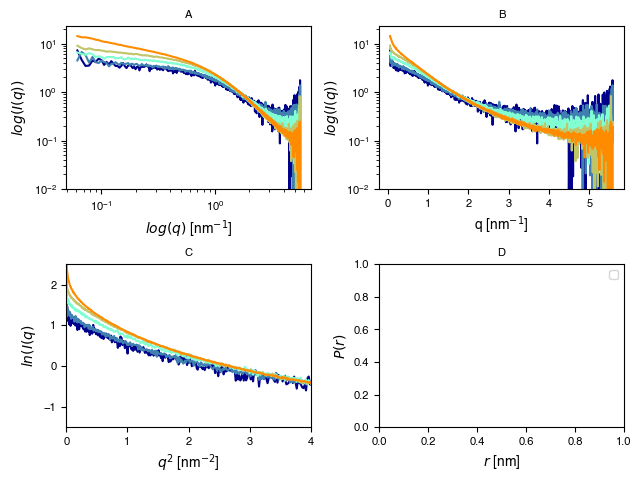

In [30]:
def plot_func(path, scale, c):
    q, I = np.genfromtxt((work_dir + path), skip_header=3, skip_footer=9, usecols=(0, 1), unpack=True)
    I = I*scale
    ax[0, 0].plot(q, I, color=color_list[c])
    ax[0, 1].plot(q, I, color=color_list[c])
    ax[1, 0].plot((q**2), np.log(I), color=color_list[c])

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=((16*cm), (12*cm)), layout='constrained')
plot_func('0p4.dat', 1, 0)
plot_func('0p8.dat', 0.55, 25)
plot_func('1p6.dat', 0.35, 50)
plot_func('3p2.dat', 0.21, 75)
plot_func('6p4.dat', 0.11, 99)

def PDDF_func(path):
    with open(path) as PDDF:
        with open('/Users/oskarsvensson/Science/FILES/ARTICLES/Ref.out', 'r') as reference_file:
            lines = reference_file.readlines()
            ref = lines[160]
        lines = PDDF.readlines()
        counter = 0
        for line in lines:
            if line == ref:
                start_line = counter + 2
            counter += 1
            
    r, P = np.genfromtxt(path, skip_header=start_line, unpack=True, usecols=(0, 1))
    step = r[1] - r[0]
    area = []
    for p in P:
        area.append(step*p)
    scaling_factor = 1/sum(area)
    P = P*scaling_factor
    return r, P

#r, P = PDDF_func(work_dir + 'monomeric/jan2025_150_0p21mg.out')
#ax[1, 1].plot(r, P, color=color_list[0])
#r, P = PDDF_func(work_dir + 'jan2025_150_4p7mg.out')
#ax[1, 1].plot(r, P, color=color_list[-1])

ax[0, 0].set_xlabel('$log(q)$ [nm$^{-1}$]', fontsize=font_label)
ax[0, 0].set_ylabel('$log(I(q))$', fontsize=font_label)
ax[0, 0].set_title('A', fontsize=font)
ax[0, 0].set_yscale('log')
ax[0, 0].set_xscale('log')
ax[0, 0].tick_params(labelsize=font)
ax[0, 0].set_ylim(10**-2)

ax[0, 1].set_xlabel('q [nm$^{-1}$]', fontsize=font_label)
ax[0, 1].set_ylabel('$log(I(q))$', fontsize=font_label)
ax[0, 1].set_title('B', fontsize=font)
ax[0, 1].set_yscale('log')
ax[0, 1].set_ylim(10**-2)
ax[0, 1].tick_params(labelsize=font)

ax[1, 0].set_xlabel('$q^{2}$ [nm$^{-2}$]', fontsize=font_label)
ax[1, 0].set_ylabel('$ln(I(q)$', fontsize=font_label)
ax[1, 0].set_title('C', fontsize=font)
ax[1, 0].set_ylim(-1.5, 2.5)
ax[1, 0].set_xlim(0, 4)
ax[1, 0].tick_params(labelsize=font)

ax[1, 1].set_xlabel('$r$ [nm]', fontsize=font_label)
ax[1, 1].set_ylabel('$P(r)$', fontsize=font_label)
ax[1, 1].set_title('D', fontsize=font)
ax[1, 1].tick_params(labelsize=font)
ax[1, 1].legend(['0.21 mg/ml', '4.77 mg/ml'], fontsize=font)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/SAXS_spectra.pdf', dpi=1000)